# Проект спринта 8: Исследование рынка общественного питания Москвы

- Автор:Сажина Наталья 118
- Дата: 18.04.2025

### Описание проекта

Инвесторы из фонда Shut Up and Take My Money планируют открыть заведение общественного питания в Москве.
Необходимо на основе имеющихся данных выявить закономерности и определить наиболее перспективное направление развития проекта с точки зрения:
* категории заведения,
* расположения,
* ценовой категории.


### Цели и задачи

Цель проекта - на основе имеющихся данных выявить закономерности и определить наиболее перспективное направление развития проекта с точки зрения:
* категории заведения,
* расположения,
* ценовой категории.

**Задачи:**

1. Обработать данные, изучить и учесть имеющиеся пропуски и дубликаты, чтобы результаты отражали реальную ситуацию и не были искажены.
    
2. Проанализировать полученные данные и выявить основные тенденции  и закономерности рынка общественного питания Москвы с точки зрения местоположения, категории, ценовой категории, рейтинга заведения и количества посадочных мест.

### Описание данных
Доступен датасет с заведениями общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках, она носит справочный характер.

**Файл `/datasets/rest_info.csv`** содержит информацию о заведениях общественного питания:
`name` — название заведения;

`address` — адрес заведения;

`district` — административный район, в котором находится заведение, например Центральный административный округ;

`category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;

`hours` — информация о днях и часах работы;

`rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);

`chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки): `0` — заведение не является сетевым;`1` — заведение является сетевым.

`seats` — количество посадочных мест.


**Файл `/datasets/rest_price.csv`** содержит информацию о среднем чеке в заведениях общественного питания:
price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;

`avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
«Средний счёт: 1000–1500 ₽»;
«Цена чашки капучино: 130–220 ₽»;
«Цена бокала пива: 400–600 ₽».
и так далее;

`middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.

`middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца 

`avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.


### Содержимое проекта

1. **Загрузка и знакомство с данными**

2. **Предобработка данных**

3. **Исследовательский анализ данных**

4. **Итоги и рекомендации**


## 1. Загрузка и обзор данных

In [1]:
# импортируем нужные библиотеки и модули
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

!pip install phik
from phik import phik_matrix 


     |████████████████████████████████| 686 kB 1.3 MB/s eta 0:00:01


In [2]:
df_rests = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
df_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [3]:
df_rests.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
df_rests['id'].nunique() # проверим уникальность идентификаторов

8406

In [5]:
df_rests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк с информацией о точках общественного питания с их категориями, местоположением, часами работы, рейтингом, количеством посадочных мест и данными о принадлежности к сетям. По первичной оценке данных:
* Столбцы имеют оптимальные названия и не требуют переименования.
* В столбцах `hours` и `seats` есть существенная доля пропущенных значений. В остальных столбцах нет очевидных пропусков, но требуется дополнительно проверить их на наличие индикаторов.
* Столбцы `id`,`name`,`category`,`address`,`district`,`hours` имеют тип `object`. Для `category` и `district` корректно поменять тип на `category`. Столбцы `rating` и `seats` имеют тип float64. Для `rating` это корректно, а `seats` может быть представленно только целым числом, необходимо поменять на `int` с оптимальной битностью. Булевый столбец `chain` имеет тип `int64`, что соотвествует содержащимся целочисленным значениям, однако для оптимизации процессов битность необходимо понизить.
* Столбец `id` содержит в себе уникальные идентификаторы.
* Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

In [6]:
df_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
df_price['id'].nunique()

4058

In [8]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датесет `rest_price.csv` содержит 5 столбцов и 4058 строк с данными о ценах в точках общественного питания:
* Названия столбцов соответствуют snake case, переименование не требуется.
* Значения в столбце `id` уникальны. Столбец может быть использован для объединения датасетов. Необходимо учитывать, что в датасете с ценами строк меньше, чем в датасете с общей информациях о точках общественного питания (далее ТОП). Поэтому при объединении нужно использовать left, где левый датафрейм - это `df_rests`.
* Столбцы `id`, `price`, `avg_bill` имеют тип `object`, для столбца `price` корректно поменять тип на `category`. Столбцы `middle_avg_bill`, `middle_coffee_cup` имеют тип данных подходящий для денежных значений - `float64`.
* Датасет содержит большое количество пропусков во всех столбцах, кроме `id`. В столбце `middle_coffee_cup` пропущена большая часть значений.

In [9]:
df = df_rests.merge(df_price, how = 'left', on = 'id') # объединяю датафреймы левым присоединением, чтобы не потерять данные из датасета с общей информацией о ТОП.

print(f'Объединенный датафрейм')
df.head(7)

Объединенный датафрейм


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN,средние,NaN,NaN,NaN
6,96ebceb1a09e4e3191133b9fe0379a64,Огни города,"бар,паб","Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45.0,средние,Средний счёт:199 ₽,199.0,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


В результате загрузки и обзора данных получен объединенный датафрейм и общее представление о имеющихся данных:
1. Всего имеем 8406 строк с информацией о точках общественного питания. Предполагаем, что значения уникальны т.к. в столбце id нет явных дубликатов, однако в ходе предобработки данных необходимо проверить наличие неявных дубликатов по сочетания названия и адреса заведения.
2. Для части столбцов необходимо изменить тип данных: `category`, `district`, `price` поменять тип на `category`. Для столбцов `seats`, `chain` выбрать тип `int` с оптимальной битностью.
3. В объединенном датафрейме имеется существенное количество пропусков, особенно в ценовых столбцах.

## 2. Предобработка данных
#### 2.1 Типы данных

In [11]:
# приведем столбцы seats и chain к оптимальному целочисленному формату
 
df_types = df
df_types['seats'] = df_types['seats'].fillna(0) #меняем пропуски на 0, такого значения не может быть в столбце с количеством мест, оно послужит индикатором пропуска
df_types['seats'] = df_types['seats'].astype('int64') #приводим к целочисленому типу

df_types['seats'] = pd.to_numeric(df_types['seats'], downcast = 'integer')

df_types['chain'] = pd.to_numeric(df_types['chain'],downcast = 'integer')

df_types.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int8   
 8   seats              8406 non-null   int16  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(3), int16(1), int8(1), object(8)
memory usage: 812.7+ KB


Теперь типы данных столбцов соответствуют значениям

#### 2.2 Наличие пропусков в данных

In [12]:
print(f'Абсолютное количество пропусков по столбцам')
df_types.isna().sum() 

Абсолютное количество пропусков по столбцам


id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                   0
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [13]:
print(f'Доля пропусков по столбцам')
df_types.isna().mean() 

Доля пропусков по столбцам


id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.000000
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

Пропуски найдены в следующих столбцах:
* `hours` - 6%. Можем заменить на индикатор - строку 'нет данных';
* `price`, `avg_bill` - 54% - 60%. Появление такого большого количества пропусков в объединенным датафрейме связанно с тем, что в исходном датасете с данными о ценах было меньше строк. Так же заменим на индикаторы - строку 'нет данных' для корректной группировки данных по этоим признакам.
* `middle_avg_bill`, `middle_coffee_cup` так же имеют большое количество пропусков - от 62% до 93%. Это вызвано во-первых той же причиной, что у столбцов `price` и `avg_bill`, во-вторых тем, что столбцы `middle_avg_bill`, `middle_coffee_cup` сформированны из значений `avg_bill`, поэтому не могут иметь меньше пропусков. Это числовые столбцы, оставим пропуски без изменений, чтобы в дальнейшем индикаторы не повлияли на расчеты


In [14]:
df_nona = df_types
df_nona[['hours','price','avg_bill']] = df_nona[['hours','price','avg_bill']].fillna('нет данных')
df_nona.isna().mean()

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.000000
rating               0.000000
chain                0.000000
seats                0.000000
price                0.000000
avg_bill             0.000000
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

Обработаны пропуски в объединенном датасете:
* пропуски в числовом столбце `seats` заменены на индикатор 0;
* пропуски в строковых столбцах `hours`, `price`, `avg_bill` заменены на индикатор 'нет данных' для удобства группировки;
* пропуски в числовых столбцах `middle_avg_bill`, `middle_coffee_cup` учтены и оставлены без изменений.
  
#### 2.3 Наличие дубликатов в данных

In [15]:
df_nona.duplicated().sum() #мы уже проверяли уникальность значений в столбце id, убедимся в отсутствии явных дубликатов

0

Явных дубликатов нет, изучим уникальные значения в категориальных данных: проверим, встречаются ли среди данных неявные дубликаты, связанные с опечатками или разным способом написания.

In [16]:
unique_cat = df_nona['category'].unique()
ser_cat = pd.Series(unique_cat) #преобразовала массив в series, чтобы отсортировать результат, так наличие неявных дубликатов будет нагляднее
ser_cat.sort_values()

4            бар,паб
6           булочная
5    быстрое питание
0               кафе
2            кофейня
3           пиццерия
1           ресторан
7           столовая
dtype: object

В столбце с категориями не найдено неявных дубликатов.

Сделаем то же самое для столбца с районом:

In [17]:
unique_district = df_nona['district'].unique()
ser_district = pd.Series(unique_district) 
ser_district.sort_values()

5           Восточный административный округ
3            Западный административный округ
0            Северный административный округ
1    Северо-Восточный административный округ
2     Северо-Западный административный округ
4         Центральный административный округ
6       Юго-Восточный административный округ
8        Юго-Западный административный округ
7               Южный административный округ
dtype: object

В cтолбце с районом местоположения нет неявных дуливатов.

Проверим столбец с ценовой категорией заведения:

In [18]:
unique_price = df_nona['price'].unique()
ser_price = pd.Series(unique_price) 
ser_price.sort_values()

3          высокие
1    выше среднего
0       нет данных
4           низкие
2          средние
dtype: object

В столбце с ценовой категорией так же нет неявных дубликатов. Категориальные столбцы проверены и не требуют изменения значений.

Теперь проверим наличие дубликатов в сочетаниях названия и адреса, оно должно быть уникальным. Начнем с нормализации данных:

In [19]:
df_unique = df_nona
df_unique['lower_name'] = df_unique['name'].str.lower() #создадим новый столбец с названием в нижнем регистре, чтобы сохранить реальные названия для выводов
df_unique['address'] = df_unique['address'].str.lower()

df_unique.duplicated(subset = ['lower_name','address']).sum()


4

Нашлось 4 дубликата с одинаковым сочетанием названия и адреса. Удалим их:

In [20]:
df_no_dupl = df_unique.drop_duplicates(subset = ['lower_name','address'])
df_no_dupl = df_no_dupl.reset_index() #сбрасываем индекс, т.к. из-за удаления дубликатов в последовательности индексов образовались пробелы
df_no_dupl = df_no_dupl.drop('index', axis = 1) #удаляем лишние столбцы, которые образовались из-за подмены индексов 
df_no_dupl = df_no_dupl.drop('lower_name', axis = 1) #удаляем столбец с названием в нижнем регистре, он больше не понадобится
df_no_dupl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8402 entries, 0 to 8401
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              8402 non-null   object 
 6   rating             8402 non-null   float64
 7   chain              8402 non-null   int8   
 8   seats              8402 non-null   int16  
 9   price              8402 non-null   object 
 10  avg_bill           8402 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(3), int16(1), int8(1), object(8)
memory usage: 746.8+ KB


Проведена обработка дубликатов:
1. Датафрейм проверен на наличие явных дубликатов - их не нашлось.
2. Категориальные столбцы проверены на наличие неявных дубликатов: все категориальные значения в исходных данных уникальны.
3. Сочетание столбцов с названием и адресом заведения проверено на наличие неявных дубликатов через нормализацию данных. Найдено четыре дублирующихся значения. Все повторяющиеся значения, кроме первого встреченного, удалены.

После удаления дубликатов в датафрейме имеем 8402 строки, всего удалено 4 строки. 

#### 2.4 Выделение новых столбцов для рассчетов

Для дальнейшей работы необходим булевый столбец с обозначением признака круглосуточности заведения.

In [21]:
day_and_night = df_no_dupl['hours'].str.contains('круглосуточно',case = False) #посчитаем, сколько всего строк содержит подстроку 'круглосуточно' без учета регистра
day_and_night.sum()

772

In [22]:
df_with24_7 = df_no_dupl #создаем новый датафрейм
df_with24_7['is_24_7'] = df_with24_7['hours'].str.contains('круглосуточно', case = False) #добавляем столбец с признаком
df_with24_7.head(12)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"москва, улица дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,0,нет данных,нет данных,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"москва, клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"москва, улица маршала федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,0,нет данных,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148,средние,Средний счёт:400–600 ₽,500.0,NaN,False
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"москва, ижорская улица, вл8б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,0,средние,нет данных,NaN,NaN,False
6,96ebceb1a09e4e3191133b9fe0379a64,Огни города,"бар,паб","москва, клязьминская улица, 9, стр. 3",Северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45,средние,Средний счёт:199 ₽,199.0,NaN,False
7,0243288b78024af090b8e947842c969c,Mr. Уголёк,быстрое питание,"москва, клязьминская улица, 9, стр. 3",Северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,0,45,средние,Средний счёт:200–300 ₽,250.0,NaN,False
8,36aeb0ffa69c48fdb0021549520deb10,Donna Maria,ресторан,"москва, дмитровское шоссе, 107, корп. 4",Северный административный округ,"ежедневно, 10:00–22:00",4.8,0,79,средние,Средний счёт:от 500 ₽,500.0,NaN,False
9,487167877eb04288bc90d4fa80646fc2,Готика,кафе,"москва, ангарская улица, 39",Северный административный округ,"ежедневно, 12:00–00:00",4.3,0,65,средние,Средний счёт:1000–1200 ₽,1100.0,NaN,False


In [23]:
df_with24_7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8402 entries, 0 to 8401
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              8402 non-null   object 
 6   rating             8402 non-null   float64
 7   chain              8402 non-null   int8   
 8   seats              8402 non-null   int16  
 9   price              8402 non-null   object 
 10  avg_bill           8402 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
 13  is_24_7            8402 non-null   bool   
dtypes: bool(1), float64(3), int16(1), int8(1), object(8)
memory usage: 755.0+ KB


#### Результаты предобработки данных
Проведена работа:
1. Столбцы 'seats' и 'chain' были приведены к оптимальному целочисленному формату. В результате использование памяти снизилось с 853.9+ KB исходных до  747.1+ KB.
2. Изучены и обработаны пропуски:
   * пропуски в числовом столбце `seats` заменены на индикатор 0;
   * пропуски в строковых столбцах `hours`, `price`, `avg_bill` заменены на индикатор 'нет данных' для удобства группировки;
   * пропуски в числовых столбцах `middle_avg_bill`, `middle_coffee_cup` учтены и оставлены без изменений.
3. Проведена обработка дубликатов:
   * Датафрейм проверен на наличие явных дубликатов - их не нашлось.
   * Категориальные столбцы проверены на наличие неявных дубликатов: все категориальные значения в исходных данных уникальны.
   * Сочетание столбцов с названием и адресом заведения проверено на наличие неявных дубликатов через нормализацию данных. Найдено четыре дублирующихся значения. Все повторяющиеся значения, кроме первого встреченного, удалены.

   После удаления дубликатов в датафрейме имеем 8402 строки, всего удалено 4 строки.

4. Для дальнейших расчетов добавлен столбец с признаком круглосуточности заведения 'is_24_7'.

В результате имеем датафрейм с 14 столбцами и 8402 строками. Все данные соответствуют выбранному типу, дубликатов нет. Есть пропуски в столбцах `middle_avg_bill`, `middle_coffee_cup` - 62% и 93% соответственно - они учтены и оставлены без изменений.

## 3. Исследовательский анализ данных
#### 3.1 Категории заведений
Исследуем количество объектов общественного питания по каждой категории.

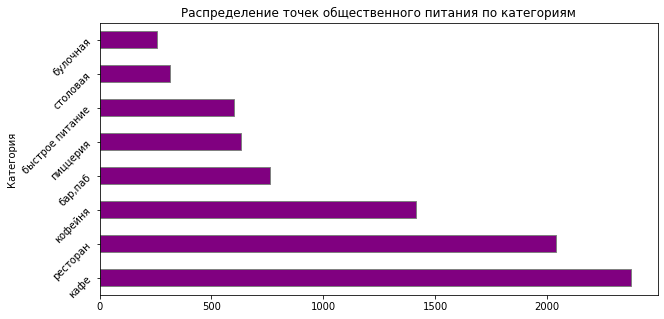

In [24]:
plt.figure(figsize = (10,5))

ax = df_with24_7['category'].value_counts().plot(
                                            kind = 'barh',
                                            rot = 45,
                                            xlabel = 'Количество заведений',
                                            color = 'purple',
                                            edgecolor = 'grey')

plt.title('Распределение точек общественного питания по категориям')
plt.ylabel('Категория')

plt.show()

На столбчатой диаграмме, отражающей распределение точек общественного питания по категориям, видим, что чаще других встречаются заведения категорий Кафе, Ресторан, Кофейня - от 2376 до 1413 заведений. Значительно ниже количество Баров(пабов), Пиццерий, Быстрого питания - от 603 до 764 заведений. Минимальный значения у Столовых и Булочных: по имеющимся данным таких ТОП всего от 256 до 315.

#### 3.2 География
Задачи:
* Исследовать распределение количества заведений по административным районам Москвы.
* Исследовать распределение заведений каждой категории в ЦАО.

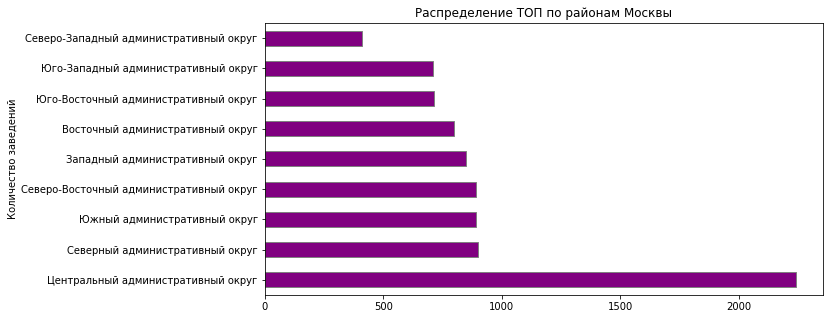

In [25]:
plt.figure(figsize = (10,5))

ab = df_with24_7['district'].value_counts().plot(
                                            kind = 'barh',
                                            xlabel = 'Количество заведений',
                                            ylabel = 'Район',
                                            color = 'purple',
                                            edgecolor = 'grey')

plt.title('Распределение ТОП по районам Москвы')

plt.show()

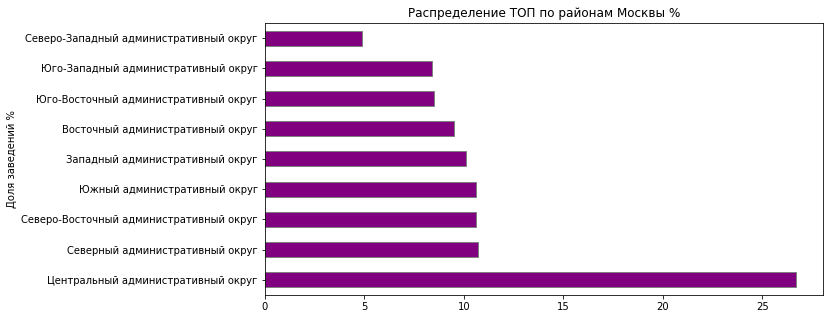

In [26]:
by_districts = round((df_with24_7.groupby('district')['id'].count() / df_with24_7['id'].count()) * 100,1) 
#Расчитаем относительные значения
by_districts = by_districts.reset_index()

by_districts = by_districts.sort_values(by = 'id', ascending = False)

ab = by_districts.plot(kind = 'barh',
                      y = 'id',
                      x = 'district', 
                      xlabel = 'Доля заведений %',
                      ylabel = 'Район',
                      color = 'purple', 
                      edgecolor = 'grey',
                      figsize = (10,5),
                      legend = False)

plt.title('Распределение ТОП по районам Москвы %')


plt.show()

Административные округи Москвы имеют явного лидера по количеству ТОП - Центральный административный округ. Он насчитывает 2242 заведения, что составляет более 26.7% от общего количества ТОП в Москве. Распределение между остальными округами равномерное - от 709 до 898 заведений, за исключением Северо-Западного административного округа - здесь всего 409 заведений. 

Для дальнейших исследований было бы полезно сравнить это соотношение с данными по округам о:
* количестве населения
* количестве работников офисов и других предприятий
* туристской нагрузке (предполагаемом количестве туристов в единицу времени)

В ходе текущего исследования рассмотрим соотношение категорий заведений внутри ЦАО:

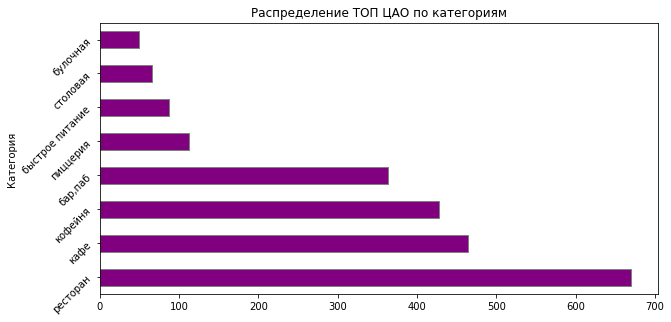

In [27]:
df_cao = df_with24_7[df_with24_7['district'] == 'Центральный административный округ'] #фильтруем датафрейм 

aс = df_cao['category'].value_counts().plot(
                                            kind = 'barh',
                                            rot = 45,
                                            xlabel = 'Количество заведений',
                                            color = 'purple',
                                            edgecolor = 'grey',
                                            figsize = (10,5))

plt.title('Распределение ТОП ЦАО по категориям')
plt.ylabel('Категория')

plt.show()


Для наглядности сравним относительные значения по категориям в Москве и в ЦАО: 

In [28]:
ser_share = round(df_with24_7.groupby('category')['id'].count() / df_with24_7['id'].count() * 100, 1)
df_share = ser_share.reset_index()
df_share = df_share.rename(columns = {'id':'share'})

ser_cao_share = round(df_cao.groupby('category')['id'].count() / df_cao['id'].count() *100, 1)
df_cao_share = ser_cao_share.reset_index()
df_cao_share = df_cao_share.rename(columns = {'id':'cao_share'})

df_merged_share = df_share.merge(df_cao_share, how = 'outer', on = 'category')

df_merged_share = df_merged_share.sort_values(by = 'share', ascending = False)


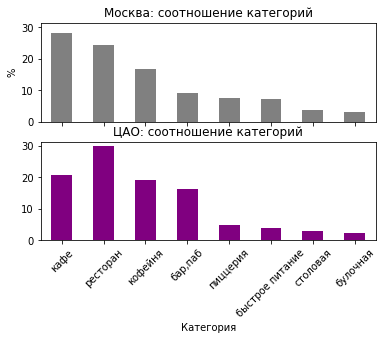

In [29]:
axes = df_merged_share.plot(kind = 'bar', subplots = True, sharex = True, sharey = True, x = 'category', 
                            title = ('Москва: соотношение категорий','ЦАО: соотношение категорий'), legend = False, color = ('grey','purple'), rot = 45)
axes[0].set_ylabel('%')
plt.xlabel('Категория')
plt.show()

В ЦАО рестораны значительно опережают кафе в отличии от ситуации по Москве в целом, большее отставание показывают категории Пиццерия и Быстрое питание - для ЦАО такие заведения менее свойственны, чем для Москвы в целом. В остальном соотношение представленности категорий очень похоже.

#### 3.3 Сетевые заведения
Задачи:
* Изучить соотношение сетевых и несетевых заведений в целом
* Изучить соотношение сетевых и несетевых заведений в разрезе категорий

In [30]:
print(f'Распределение данных по значениям столбца chain')
print(df_with24_7['chain'].value_counts(normalize = True))


Распределение данных по значениям столбца chain
0    0.618781
1    0.381219
Name: chain, dtype: float64


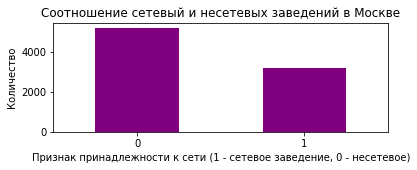

In [31]:
df_with24_7['chain'].value_counts().plot(kind = 'bar', color = 'purple', figsize = (6,2), rot = 0)
plt.title('Соотношение сетевый и несетевых заведений в Москве')
plt.xlabel('Признак принадлежности к сети (1 - сетевое заведение, 0 - несетевое)')
plt.ylabel('Количество')

plt.show()

В целом в Москве большая часть заведений - 62% -  не сетевые. 

Рассмотрим соотношение в разрезе категорий:

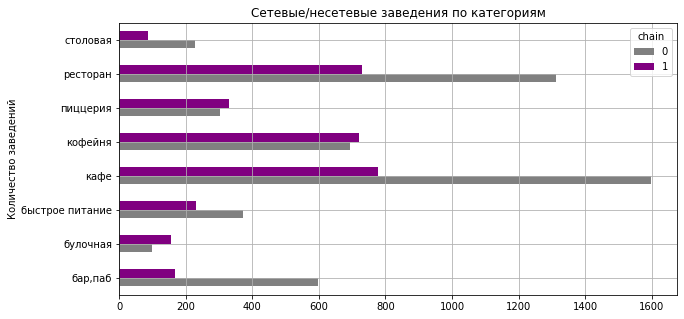

In [32]:
grouped = df_with24_7.groupby('category')['chain'].value_counts().unstack(fill_value = 0)
grouped.plot(kind = 'barh', title = 'Сетевые/несетевые заведения по категориям',
             legend = True,  ylabel = 'Категория', xlabel = 'Количество заведений',
             figsize = (10,5), color = ('gray','purple'), rot = 0)

plt.grid(True)

plt.show()

Доли сетевых заведений в разных категориях значительно отличаются и не имеют общей тенденции. Можно выявить два основных типа соотношений:
1. Для Кафе, Ресторанов, Баров(пабов), Столовых несетевых заведений встречаются чаще, чем сетевые. В категории Быстрое питание несетевых заведений так же больше, но расхождение не такое большое.
2. Для Кофеен, Булочных и Пиццерий сетевых заведений больше, но преобладание незначительное.

Даже при таком соотношении тройка категорий-лидеров по абсолютному количеству сетевых заведений: Кафе, Ресторан, Кофейня. Это связано с тем, что в целом кафе  и ресторанов в Москве значительно больше, чем заведений других категорий.

#### 3.4 Количество посадочных мест
Задачи:
* Исследовать данные на предмет выбросов.
* Выявить наиболее типичное количество посадочных мест для каждой категории.
   

In [33]:
df_seats = df_with24_7
df_seats['seats'].describe()



count    8402.000000
mean       61.802904
std       107.160755
min         0.000000
25%         0.000000
50%        20.000000
75%        85.000000
max      1288.000000
Name: seats, dtype: float64

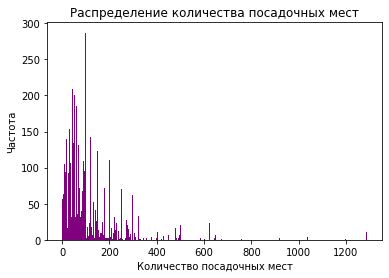

In [34]:
df_seats = df_seats[df_seats['seats'] > 0] #отфильтруем данные, чтобы не учитывать индикаторы пропусков (0)

df_seats['seats'].plot(kind = 'hist', bins = 400, color = 'purple', rot = 0)

plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')

plt.show()


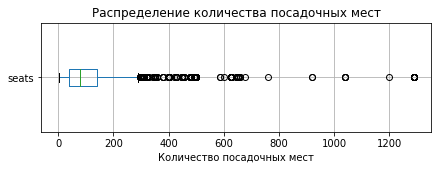

In [35]:
plt.figure(figsize = (7,2))

df_seats.boxplot(column = 'seats', vert = False)
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')

plt.show()

Среднее значение значительно больше медианы, что говорит об асимметрии и подтверждается графиком - видим ассиметричное распределение c правосторонним перекосом: хвост распределения тянется вправо, а пик смещен влево. 
На диаграмме размаха видим большое количество правых выбросов. О данных можно сказать следующее:
1. Есть большое количество положительных выбросов, в том числе аномальных - ресторанов с количеством посадочных мест более 1288.
2. Имеются рестораны с 1-3 посадочными местами. Они не отображаются как выбросы на диаграмме размаха, но вызывают сомнения и требуют дополнительной проверки.
3. 
Рассмотрим подробнее заведения с аномальным количеством посадочных мест:


In [36]:
df_min_seats = df_seats[df_seats['seats'] < 2]
print(df_min_seats[['name','address','seats']])

                name                              address  seats
497      Донер Кебаб       москва, бульвар яна райниса, 8      1
807           Шаурма  москва, путевой проезд, 14, корп. 2      1
6917      Масала Арт          москва, улица бутлерова, 24      1
7712  Домино'с Пицца      москва, россошанский проезд, 3г      1


Заведения с аномально маленьким количеством посадочных мест (до 3 включительно) либо работают на доставку и самовывоз, либо указали количество мест с ошибкой. В любом случае при расчете показателей по количеству посадочных мест их не будем учитывать.

In [37]:
df_max_seats = df_seats[df_seats['seats'] > 1200]
print(df_max_seats[['name','address','seats']])

                    name                                     address  seats
6514         DelonixCafe   москва, проспект вернадского, 94, корп. 1   1288
6520           Ян Примус  москва, проспект вернадского, 121, корп. 1   1288
6570              Мюнгер   москва, проспект вернадского, 97, корп. 1   1288
6637    One Price Coffee    москва, проспект вернадского, 84, стр. 1   1288
6654              ГудБар   москва, проспект вернадского, 97, корп. 1   1288
6680     Пивной ресторан  москва, проспект вернадского, 121, корп. 1   1288
6686      Японская кухня  москва, проспект вернадского, 121, корп. 1   1288
6767               Точка    москва, проспект вернадского, 84, стр. 1   1288
6803  Loft-cafe академия    москва, проспект вернадского, 84, стр. 1   1288
6804        Яндекс Лавка    москва, проспект вернадского, 51, стр. 1   1288
6834  Alternative coffee    москва, проспект вернадского, 41, стр. 1   1288


Заведения с 1288 посадочными местами - очевидно техническая ошибка, все они находятся на Проспекте Вернадского и не могут быть такими большими. Например, в списке содержится Яндекс Лавка, которая вообще не может иметь посадочных мест. При расчете показателей по количеству посадочных мест не учитываем такие заведения.

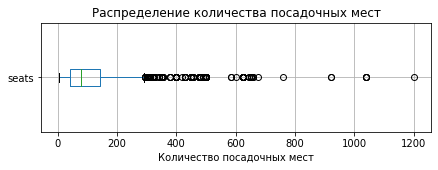

In [38]:
df_seats = df_seats[(df_seats['seats'] >= 3) & (df_seats['seats'] <= 1200)]

plt.figure(figsize = (7,2))
df_seats.boxplot(column = 'seats', vert = False)
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')

plt.show()

In [39]:
df_seats['seats'].describe()

count    4626.000000
mean      109.179853
std       109.221386
min         3.000000
25%        40.000000
50%        79.000000
75%       141.000000
max      1200.000000
Name: seats, dtype: float64

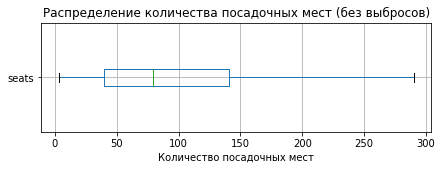

In [40]:
plt.figure(figsize = (7,2))

df_seats.boxplot(column = 'seats', vert = False, showfliers = False)
plt.title('Распределение количества посадочных мест (без выбросов)')
plt.xlabel('Количество посадочных мест')

plt.show()

Половина заведений с данными о количестве посадочных мест имеют от 40 До 141 места. Среднее значение 109 посадочный мест с достаточно большим стандартным отклонением - тоже 109, что говорит о том, что разнообразие в данных по рассматриваемому признаку велико: часто встречаются как заведения с очень маленьким количеством посадочных мест, так и с очень большим. 

In [41]:
#расcчитаем моду количества посадочных мест в разрезе категорий ТОП с помощью цикла
categories = df_seats['category'].unique()
by_cat = {}

for cat in categories:
    df_cat = df_seats[df_seats['category'] == cat]
    by_cat[cat] = df_cat['seats'].mode()[0]

ser_by_cat = pd.Series(by_cat)
df_by_cat = ser_by_cat.reset_index()
df_by_cat = df_by_cat.sort_values(by = 0, ascending = False)
df_by_cat.set_index(keys = 'index', inplace = True)

print(df_by_cat)


                   0
index               
ресторан         100
кофейня          100
бар,паб           60
булочная          48
кафе              40
пиццерия          40
быстрое питание   40
столовая          40


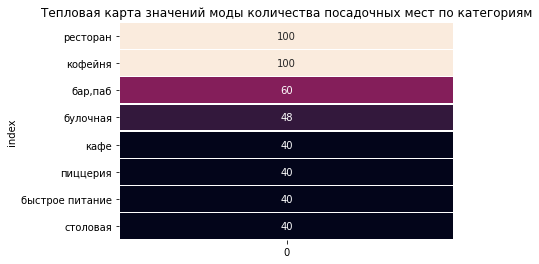

In [42]:
sns.heatmap(df_by_cat,
            annot=True,
            linewidths=0.5,
            cbar=False, fmt = '.0f' 
           )
plt.title('Тепловая карта значений моды количества посадочных мест по категориям')

plt.show() 

In [62]:
#расcчитаем медиану количества посадочных мест в разрезе категорий с помощью цикла
categories = df_seats['category'].unique()
by_cat_median = {}

for cat in categories:
    df_cat = df_seats[df_seats['category'] == cat]
    by_cat_median[cat] = df_cat['seats'].median()

ser_by_cat_median = pd.Series(by_cat_median)
df_by_cat_median = ser_by_cat_median.reset_index()
df_by_cat_median = df_by_cat_median.sort_values(by = 0, ascending = False)
df_by_cat_median.set_index(keys = 'index', inplace = True)

print(df_by_cat_median)


                    0
index                
ресторан         90.0
бар,паб          83.0
столовая         80.0
кофейня          80.0
быстрое питание  75.0
кафе             60.0
пиццерия         56.0
булочная         52.0


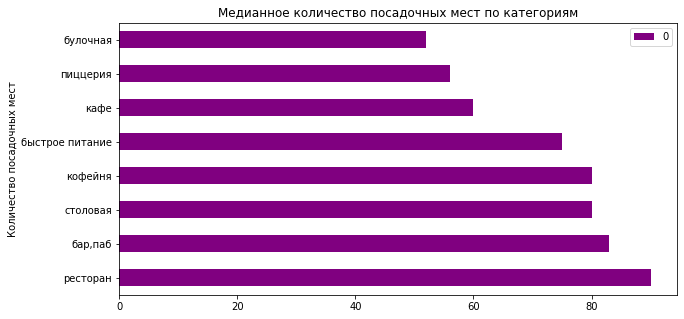

In [65]:
df_by_cat_median.plot(kind = 'barh', color = 'purple', figsize = (10,5),
                      title = 'Медианное количество посадочных мест по категориям',
                      xlabel = 'Количество посадочных мест', ylabel = 'Категория')

plt.show()

Лидеры по размеру моды количества посадочных мест - категории Ресторан и Кофейня, для них наиболее частое значение 100 посадочных мест на заведение.
Для баров и пабов наиболее типично количество мест 60, для булочных - 48. Остальные категории имеют самое распростанненное количество мест - 40.

#### 3.5 Рейтинг заведений
* Изучить распределение значений рейтинга
* Изучить распределение средних рейтингов по категориям заведений

In [44]:
df_with24_7['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

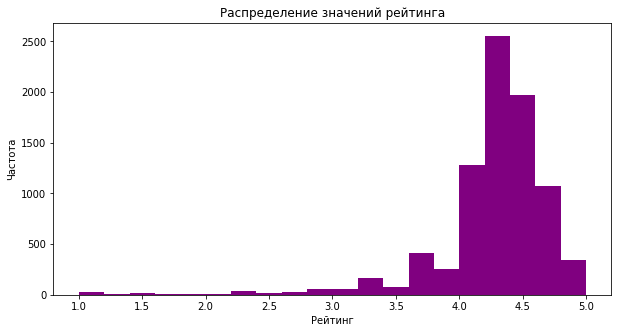

In [45]:
df_with24_7['rating'].plot(kind = 'hist', color = 'purple', 
                           figsize = (10,5), bins = 20)

plt.title('Распределение значений рейтинга')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')

plt.show()

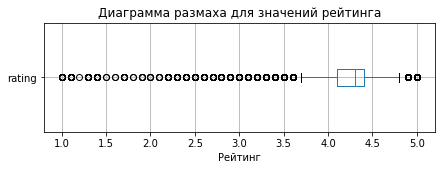

In [46]:
df_with24_7.boxplot(column = 'rating', vert = False, figsize = (7,2))

plt.title('Диаграмма размаха для значений рейтинга')
plt.xlabel('Рейтинг')
plt.show()

Значения рейтинга плотно сгруппированы, межквартильный размах составляет всего 0,3 - половина значений находятся в промежутке от 4,1 до 4,3 баллов. Распределение является левосимметричным - с длинным левым хвостом и пиком смещенным вправо. На гистограмме и диаграмме размаха видим наличие большого количества отрицательных выбросов.

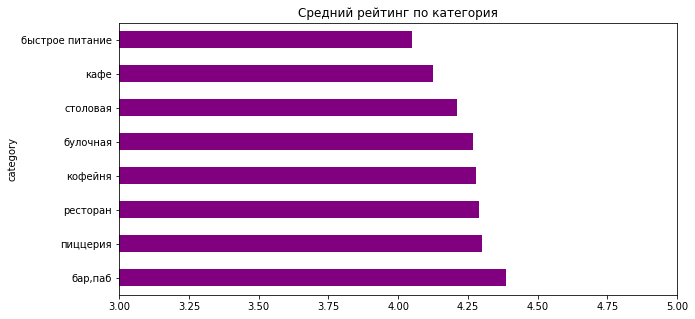

In [47]:
mean_rate = df_with24_7.groupby('category')['rating'].mean()

df_rate_by_cat = mean_rate.reset_index()

df_rate_by_cat = df_rate_by_cat.sort_values(by = 'rating', ascending = False)

df_rate_by_cat.set_index(keys = 'category', inplace = True)

ad = df_rate_by_cat['rating'].plot(kind = 'barh', color = 'purple', figsize = (10,5), xlim = (3,5))

plt.title('Средний рейтинг по категория')
plt.show()

Средний рейтинг в разрезе категорий показывает очень близкие значения: от 4,05 для Столовых до 4,38 для Баров(пабов). Это говорит о том, что отрицательные выбросы распределены между категориями относительно равномерно и не оказывают значительного влияния на соотношение. Можно сделать вывод, что клиенты в среднем примерно одинаково оценивают заведения вне зависимости от категории, при этом немного более лояльны по отношению к Барам и немного менее лояльны к заведениям Быстрого питания.

#### 3.6 Корреляция рейтинга с другими переменными
* Изучить, с какими данными показывают самую сильную корреляцию рейтинги заведений.
* Проверить самую сильную связь

In [48]:
corr_matrix = df_with24_7[['rating','category','district','chain','price','is_24_7','seats']].phik_matrix()

print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending = False)

interval columns not set, guessing: ['rating', 'chain', 'seats']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.281253
district,0.200761
category,0.189716
is_24_7,0.144951
chain,0.107833
seats,0.000000


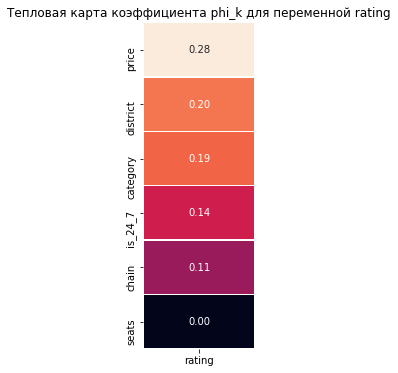

In [49]:
plt.figure(figsize = (2,6))

data_heatmap = corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending = False)
sns.heatmap(data_heatmap, annot = True, linewidths = 0.5, fmt = '.2f', cbar = False)

plt.title('Тепловая карта коэффициента phi_k для переменной rating')

plt.show()

Наиболее выраженную корреляцию с рейтингом заведения показывает переменная с ценовой категорией. Коэффициент корреляции между этими значениями выше, чем с другими переменными, однако является слабо выраженным, рассмотрим подробнее взаимосвязь переменных:

/tmp/ipykernel_48/2916305864.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_without_noprice['price'] = df_without_noprice['price'].replace({'низкие':'1 низкие','средние':'2 средние','выше среднего':'3 выше среднего', 'высокие':'4 высокие'})


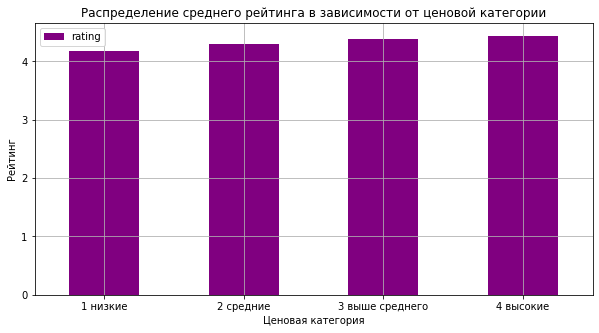

In [50]:
df_without_noprice = df_with24_7[df_with24_7['price'] != 'нет данных']
df_without_noprice['price'] = df_without_noprice['price'].replace({'низкие':'1 низкие','средние':'2 средние','выше среднего':'3 выше среднего', 'высокие':'4 высокие'})

rate_by_price = df_without_noprice.groupby('price')['rating'].mean()
ae = rate_by_price.plot(kind = 'bar', legend = True, ylabel = 'Рейтинг', xlabel = 'Ценовая категория',
                   figsize = (10,5), rot = 0, color = 'purple')

plt.title('Распределение среднего рейтинга в зависимости от ценовой категории')
plt.grid()
plt.show()

На диаграмме показано, что рейтинг заведения и его ценовая категория имеют слабо выраженную прямую связь: чем выше ценовая категория заведения тем более вероятна высокая оценка для него. Это укладывается в интуитивную логику: более дорогие заведения предлагают лучший уровень сервиса и лучшие блюда, соответственно получают более высокую оценку. Необходимо учитывать, что связь выраженна слабо, размах значений между минимальным для низкой ценовой категории и максимальным для высокой ценовой категории составляет всего 0,26.

#### 3.7 Топ-15 популярных сетей в Москве
* Построить топ-15 сетей.
* Посчитать значений среднего рейтинга для сетей в топе.
* Определить категории популярных сетей



In [51]:
grouped_by_name = df_with24_7.groupby('name').agg({'id':'count','category':'min'})
df_chains = grouped_by_name.reset_index()
df_chains = df_chains.rename(columns = {'id':'amount'})
df_chains = df_chains.sort_values(by = 'amount', ascending = False)

df_chains.head(15)


,name,amount,category
2890,Кафе,188,"бар,паб"
5521,Шоколадница,120,кафе
2584,Домино'с Пицца,76,пиццерия
2551,Додо Пицца,74,пиццерия
1156,One Price Coffee,71,кофейня
5594,Яндекс Лавка,69,ресторан
419,Cofix,65,кофейня
1290,Prime,50,кафе
5083,Хинкальная,44,"бар,паб"
5420,Шаурма,43,булочная


In [52]:
#в названиях явно ошибка: Кафе, Шаурма, Ресторан - не являются сетями, ошибочно внесены в качестве названия заведения. Яндекс Лавка - не заведение общественного питания, ее тоже не учитываем.
df_chains_filtered = df_chains[(df_chains['name'] != 'Кафе') 
                             & (df_chains['name'] != 'Яндекс Лавка') 
                             & (df_chains['name'] != 'Шаурма') 
                             & (df_chains['name'] != 'Ресторан') ]

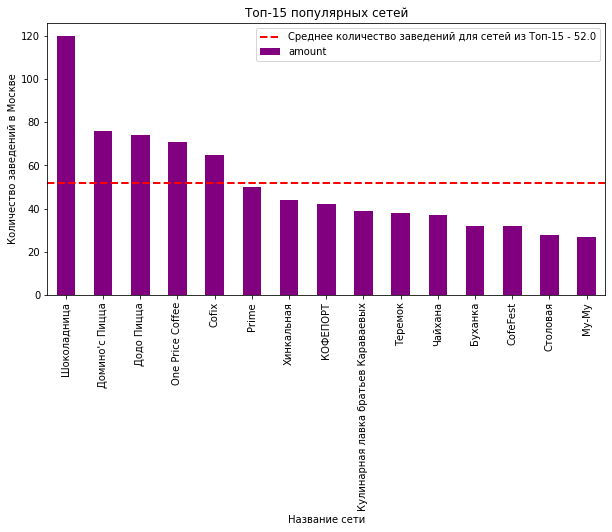

In [53]:
df_top15 = df_chains_filtered.iloc[0:15]

df_top15.set_index(keys = 'name', inplace = True)

avg_amount = df_top15.agg({'amount':'mean'})[0]

af = df_top15['amount'].plot(kind = 'bar', color = 'purple', figsize = (10,5), title = 'Топ-15 популярных сетей', 
                             xlabel = 'Название сети', ylabel = 'Количество заведений в Москве', rot = 90,)
                             

plt.axhline(avg_amount, color = 'red', linestyle = '--', linewidth = 2, label = f'Среднее количество заведений для сетей из Топ-15 - {round(avg_amount,0)}')
plt.legend()

plt.show()


После фильтрации названия в Топ-15 не содержат ошибок. С большим отрывом по количеству заведений лидирует сеть Шоколадница - она имеет 120 заведений в Москве, а следующая за ней Доминос Пицца - всего 76 заведений. Минимальное значение в рейтинге - пятнадцатое место у Му-му с 27 точками. Среднее количество заведений для сетей из Топ-15 - 52

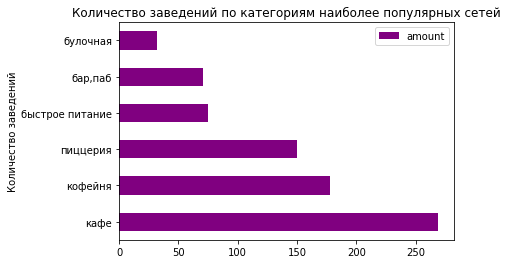

                                     amount         category
name                                                        
Шоколадница                             120             кафе
Домино'с Пицца                           76         пиццерия
Додо Пицца                               74         пиццерия
One Price Coffee                         71          кофейня
Cofix                                    65          кофейня
Prime                                    50             кафе
Хинкальная                               44          бар,паб
КОФЕПОРТ                                 42          кофейня
Кулинарная лавка братьев Караваевых      39             кафе
Теремок                                  38  быстрое питание
Чайхана                                  37  быстрое питание
Буханка                                  32         булочная
CofeFest                                 32             кафе
Столовая                                 28             кафе
Му-Му                   

In [54]:
grouped_top = df_top15.groupby('category')['amount'].sum()

df_grouped_top = grouped_top.reset_index()
df_grouped_top = df_grouped_top.sort_values(by = 'amount', ascending = False)
df_grouped_top.set_index('category', inplace = True)

df_grouped_top.plot(kind = 'barh', color = 'purple', title = 'Количество заведений по категориям наиболее популярных сетей',
                    xlabel = 'Количество заведений', ylabel = 'Категория')

plt.show()
print(df_top15)

Наиболее популярные сети имеют категории: кофе, кофейня, пиццерия, быстрое питание, бар или булочная. Самая популярная сеть - кафе Шоколадница.

#### 3.8 Вариации среднего чека
* Изучить вариации среднего чека в зависимости от района Москвы.
* Проанализировать цены в ЦАО по сравнению с другими районами.

In [55]:
df_with24_7['middle_avg_bill'].describe()

count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

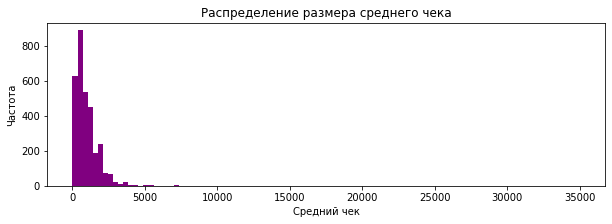

In [56]:
df_with24_7['middle_avg_bill'].plot(kind = 'hist', bins = 100, color = 'purple', rot = 0, figsize = (10,3))

plt.title('Распределение размера среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')

plt.show()


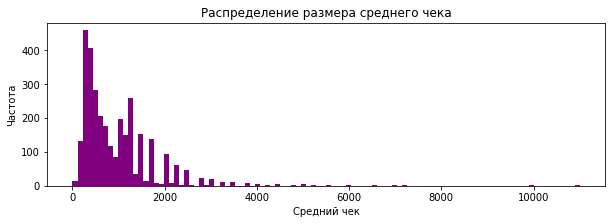

In [57]:
#на гистограмме видим выброс 35000, явно связанный с ошибкой, отфильтруем данные
df_no35 = df_with24_7[df_with24_7['middle_avg_bill'] < 30000]

df_no35['middle_avg_bill'].plot(kind = 'hist', bins = 100, color = 'purple', rot = 0, figsize = (10,3))

plt.title('Распределение размера среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')

plt.show()


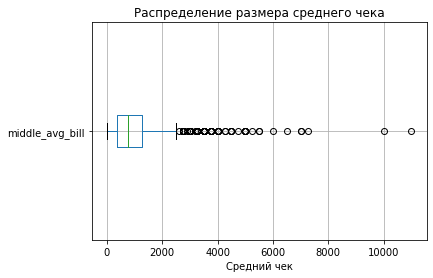

In [58]:
df_no35.boxplot(column = 'middle_avg_bill', vert = False)

plt.title('Распределение размера среднего чека')
plt.xlabel('Средний чек')
plt.show()

Распределение размера среднего чека представлено правоассиметричным графиком с длинным правым хвостом и пиком, смещенным влево. 50% значений находятся на отрезке от 350 до 1250, среднее значение 950, при этом видим большой показатель стандартного отклонения - 1009, связанный с большим разбросом значений. 

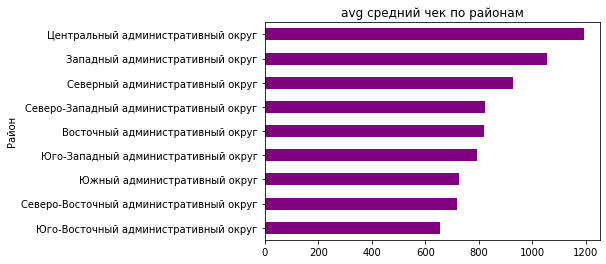

In [59]:
grouped_by_dist = df_no35.groupby('district')['middle_avg_bill'].mean()
df_grouped_by_dist = grouped_by_dist.reset_index()
df_grouped_by_dist = df_grouped_by_dist.sort_values(by = 'middle_avg_bill')
df_grouped_by_dist.set_index('district', inplace = True)

df_grouped_by_dist.plot(kind = 'barh', color = 'purple', title = 'avg средний чек по районам',
                    xlabel = 'Район', ylabel = 'avg средний чек', legend = False)

plt.show()

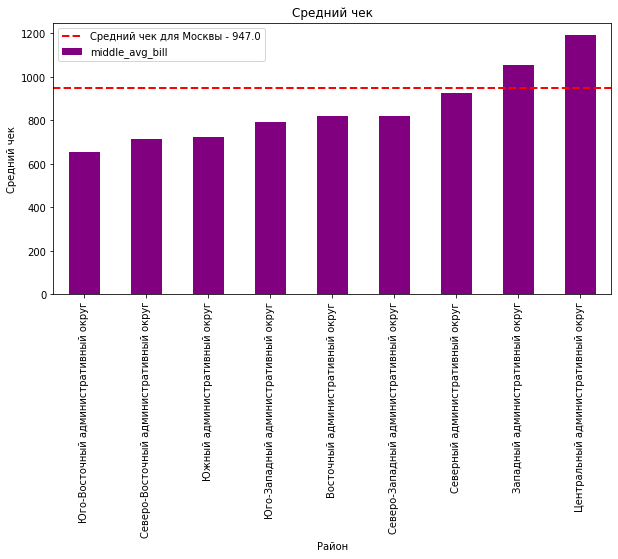

In [60]:
avg_price = df_no35.agg({'middle_avg_bill':'mean'})[0]

ag = df_grouped_by_dist['middle_avg_bill'].plot(kind = 'bar', color = 'purple', figsize = (10,5), title = 'Средний чек', 
                             xlabel = 'Район', ylabel = 'Средний чек', rot = 90,)

plt.axhline(avg_price, color = 'red', linestyle = '--', linewidth = 2, label = f'Средний чек для Москвы - {round(avg_price,0)}')
plt.legend()

plt.show()

Наибольший средний чек отмечается в Центральном административном округе, это объясняется высокой туристской нагрузкой, большим количеством дорогостоящго жилья и престижных офисных центров. В целом платежеспособность потенциальных клиентов в ЦАО выше, и рынок отвечает соответствующим предложением. Второй по размеру среднего чека раойн Москвы - Западный административный округ. Остальные районы находятся ниже средней отметки.

## 2. Итоговый вывод и рекомендации
### Проделанная работа
##### 1. Загрузка и обзор данных:

* Датафрейм проверен на наличие явных дубликатов - их не нашлось.
* Категориальные столбцы проверены на наличие неявных дубликатов: все категориальные значения в исходных данных уникальны.
* Сочетание столбцов с названием и адресом заведения проверено на наличие неявных дубликатов через нормализацию данных. Найдено четыре дублирующихся значения. Все повторяющиеся значения, кроме первого встреченного, удалены.
  
После удаления дубликатов в датафрейме имеем 8402 строки, всего удалено 4 строки.


##### 2. Предобработка данных:
2.1. Столбцы 'seats' и 'chain' были приведены к оптимальному целочисленному формату. В результате использование памяти снизилось с 853.9+ KB исходных до  747.1+ KB.
2.2. Изучены и обработаны пропуски:
   * пропуски в числовом столбце `seats` заменены на индикатор 0;
   * пропуски в строковых столбцах `hours`, `price`, `avg_bill` заменены на индикатор 'нет данных' для удобства группировки;
   * пропуски в числовых столбцах `middle_avg_bill`, `middle_coffee_cup` учтены и оставлены без изменений.
2.3. Проведена обработка дубликатов:
   * Датафрейм проверен на наличие явных дубликатов - их не нашлось.
   * Категориальные столбцы проверены на наличие неявных дубликатов: все категориальные значения в исходных данных уникальны.
   * Сочетание столбцов с названием и адресом заведения проверено на наличие неявных дубликатов через нормализацию данных. Найдено четыре дублирующихся значения. Все повторяющиеся значения, кроме первого встреченного, удалены.

   После удаления дубликатов в датафрейме имеем 8402 строки, всего удалено 4 строки.

2.4. Для дальнейших расчетов добавлен столбец с признаком круглосуточности заведения 'is_24_7'.

В результате имеем датафрейм с 14 столбцами и 8402 строками. Все данные соответствуют выбранному типу, дубликатов нет. Есть пропуски в столбцах `middle_avg_bill`, `middle_coffee_cup` - 62% и 93% соответственно - они учтены и оставлены без изменений.

##### 3. Исследовательский анализ данных:
3.1. Изучены представленные категории.

3.2. Исследовано распределение заведений по районам Москвы.

3.3. Сопоставленны сетевые и несетевые заведения.

3.4. Рассмотрено распределение по данных о количестве посадочных мест.

3.5. Изучено распределение значений рейтинга и распределение средних рейтингов по категориям заведений.

3.6. Исследована корреляция рейтинга с другими переменными.

3.7. Выделен Топ-15 наиболее популярных сетей общественного питания.

3.8. Изучены вариации среднего чека в зависимости от района Москвы, проведен анализ цен в ЦАО по сравнению с другими районами.


### Ответы на исследовательские вопросы
1. Наиболее распространены заведения категорий Кафе, Ресторан, Кофейня - от 2376 до 1413 заведений. Значительно ниже количество Баров(пабов), Пиццерий, Быстрого питания - от 603 до 764 заведений. Минимальный значения у Столовых и Булочных: по имеющимся данным таких заведений всего от 256 до 315.

2. Административные округи Москвы имеют явного лидера по количеству ТОП - Центральный административный округ. Он насчитывает 2242 заведения, что составляет более 26.7% от общего количества ТОП в Москве. Распределение между остальными округами равномерное - от 709 до 898 заведений, за исключением Северо-Западного административного округа - здесь всего 409 заведений.

В ЦАО рестораны значительно опережают кафе в отличии от ситуации по Москве в целом, большее отставание показывают категории Пиццерия и Быстрое питание для ЦАО такие заведения менее свойственны, чем для Москвы в целом. В остальном соотношение представленности категорий очень похоже.

3. Доли сетевых заведений в разных категориях значительно отличаются и не имеют общей тенденции. Можно выявить два основных типа соотношений:

* Для Кафе, Ресторанов, Баров(пабов), Столовых несетевых заведений встречаются чаще, чем сетевые. В категории Быстрое питание несетевых заведений так же больше, но расхождение не такое большое.
* Для Кофеен, Булочных и Пиццерий сетевых заведений больше, но преобладание незначительное.

Даже при таком соотношении тройка категорий-лидеров по абсолютному количеству сетевых заведений: Кафе, Ресторан, Кофейня. Это связано с тем, что в целом кафе и ресторанов в Москве значительно больше, чем заведений других категорий.

4. Половина заведений с данными о количестве посадочных мест имеют от 40 До 141 места. Среднее значение 109 посадочный мест с достаточно большим стандартным отклонением - тоже 109, что говорит о том, что разнообразие в данных по рассматриваемому признаку велико: часто встречаются как заведения с очень маленьким количеством посадочных мест, так и с очень большим. Лидеры по размеру моды количества посадочных мест - категории Ресторан и Кофейня, для них наиболее частое значение 100 посадочных мест на заведение. Для баров и пабов наиболее типично количество мест 60, для булочных - 48. Остальные категории имеют самое распростанненное количество мест - 40.

5. Значения рейтинга плотно сгруппированы: чаще всего заведения имеют рейтинг от 4,1 до 4,3 баллов. Средний рейтинг в разрезе категорий показывает очень близкие значения: от 4,05 для Быстрого питания до 4,38 для Баров(пабов). Клиенты в среднем примерно одинаково оценивают заведения вне зависимости от категории, при этом немного более лояльны по отношению к Барам и немного менее лояльны к заведениям Быстрого питания.

6. По сравнению с другими показателями наиболее выраженную корреляцию с рейтингом заведения показывает ценовая категория заведения: рейтинг заведения и его ценовая категория имеют слабо выраженную прямую связь: чем выше ценовая категория заведения тем более вероятна высокая оценка для него. Это укладывается в интуитивную логику: более дорогие заведения предлагают лучший уровень сервиса и лучшие блюда, соответственно получают более высокую оценку. Необходимо учитывать, что связь выраженна слабо, размах среднихзначений рейтинга между минимальным для низкой ценовой категории и максимальным для высокой ценовой категории составляет всего 0,26.

7. Составлен рейтинг топ-15 популярных сетей. С большим отрывом по количеству заведений лидирует сеть Шоколадница - она имеет 120 заведений в Москве, а следующая за ней Доминос Пицца - всего 76 заведений. Минимальное значение в рейтинге - пятнадцатое место у Му-му с 27 точками. Среднее количество заведений для сетей из Топ-15 - 52. Наиболее популярные сети имеют категории: кафе, кофейня, пиццерия, быстрое питание, бар или булочная. 

8. Наибольший средний чек отмечается в Центральном административном округе, это объясняется высокой туристской нагрузкой, большим количеством дорогостоящго жилья и престижных офисных центров. В целом платежеспособность потенциальных клиентов в ЦАО выше, и рынок отвечает соответствующим предложением. Второй по размеру среднего чека раойн Москвы - Западный административный округ. Остальные районы находятся ниже средней отметки.


Для дальнейших исследований было бы полезно сравнить количество заведений с данными по административным округам о:

* количестве населения,
* количестве работников офисов и других предприятий,
* туристской нагрузке (предполагаемом количестве туристов в единицу времени),

и выявить среднее количество посадочных мест на предполагаемого человека (жителя/туриста/работника).

Так можно рассчитать, в каких округах рынок общественного питания перенасыщен предложением, а в каких есть емкость для новых игроков.

### Рекомендации

**Категория** по результатам исслодования перспективной категорией для нового заведения видится Бар(паб) - такие заведения редко бывают сетевыми, значит несетевому заведению будет проще выдержать конкуренцию по ценам и уровню сервиса при формировании уникального предложения. Кроме того, по нашим данным клиенты обычно более лояльны при оценке Бара(паба) и такие заведения часто имеют более высокий рейтинг.

**Расположение** - для более точной рекомендации необходимо сравнить количество заведений с данными по административным округам о:

* количестве населения,
* количестве работников офисов и других предприятий,
* туристской нагрузке (предполагаемом количестве туристов в единицу времени),
и выявить среднее количество посадочных мест на предполагаемого человека (жителя/туриста/работника).

Так можно рассчитать, в каких округах рынок общественного питания перенасыщен предложением, а в каких есть емкость для новых игроков.

На основе имеющихся данных рекомендую рассмотреть для открытия заведения Северный административный округ или Западный административный округ. При относительно высоком среднем чеке эти округа имеют значительно меньше заведений, чем ЦАО. Есть основания полагать, что даполнительное предложение будет встречено потребителями с энтузиазмом.


**Ценовая категория** рекомендую обратить внимание на заведения с ценовой категорией выше среднего. Таким образом можно обеспечить большее высокое качество обслуживание и лояльность клиентов.